In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Семинар 2 · Ноутбук 2
# Анализ остатков

Когда мы обучили модель прогнозирования, естественно спросить: **выжали ли мы из ряда всю доступную информацию?** Ответ на этот вопрос дают **остатки** — разность между наблюдением и его одношаговым прогнозом «внутри выборки»:

$$e_t = y_t - \hat y_t.$$

Если в модели использовалось преобразование данных (например, логарифм или Бокса–Кокса), то остатки обычно смотрят *в преобразованном масштабе*, до обратного преобразования. В англоязычной литературе такие остатки называют **innovation residuals**.

## Что такое «хорошие» остатки

Хороший метод прогнозирования оставляет остатки, похожие на **белый шум**. Выделяют два **обязательных** свойства:

1. **Некоррелированность.** Если между остатками есть автокорреляция, значит в них осталась полезная информация, которую можно было бы использовать в прогнозе — метод можно улучшить.
2. **Нулевое среднее.** Если среднее остатков отлично от нуля, прогноз **смещён**. Это легко исправить: если среднее остатков равно $m$, достаточно вычесть $m$ из всех прогнозов.

Любой метод, не удовлетворяющий этим свойствам, можно улучшить. Обратное неверно: выполнение этих свойств не гарантирует, что метод — лучший (для одних и тех же данных им может удовлетворять сразу несколько методов). Проверка нужна, чтобы понять, использует ли метод всю информацию, но это не способ *выбора* модели.

Дополнительно полезны (хотя и не обязательны) ещё два свойства — они нужны для корректного построения **интервалов прогноза**:

3. **Постоянная дисперсия** (гомоскедастичность).
4. **Нормальность** распределения.

Если эти два свойства нарушены, метод не всегда можно улучшить: иногда помогает преобразование Бокса–Кокса, но чаще приходится строить интервалы прогноза альтернативными способами (например, бутстрэпом), не опираясь на нормальность.

## План ноутбука

Проверим все четыре свойства на примере **наивного прогноза** цены акций Google, затем повторим для **метода дрейфа**. Для свойств 1–2 используем графики и формальный тест Льюнга–Бокса; для свойства 3 — скользящее стандартное отклонение и тест Левене; для свойства 4 — гистограмму, Q–Q график и формальные тесты Шапиро–Уилка и Жарка–Бера. В конце разберём пример **плохой модели** — как выглядят её остатки и что с этим делать.

In [16]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings("ignore")

## Данные

Дневная цена закрытия акций Google за 2015 год. Заметный скачок — 17 июля 2015 (рост на 16% на сильном квартальном отчёте).

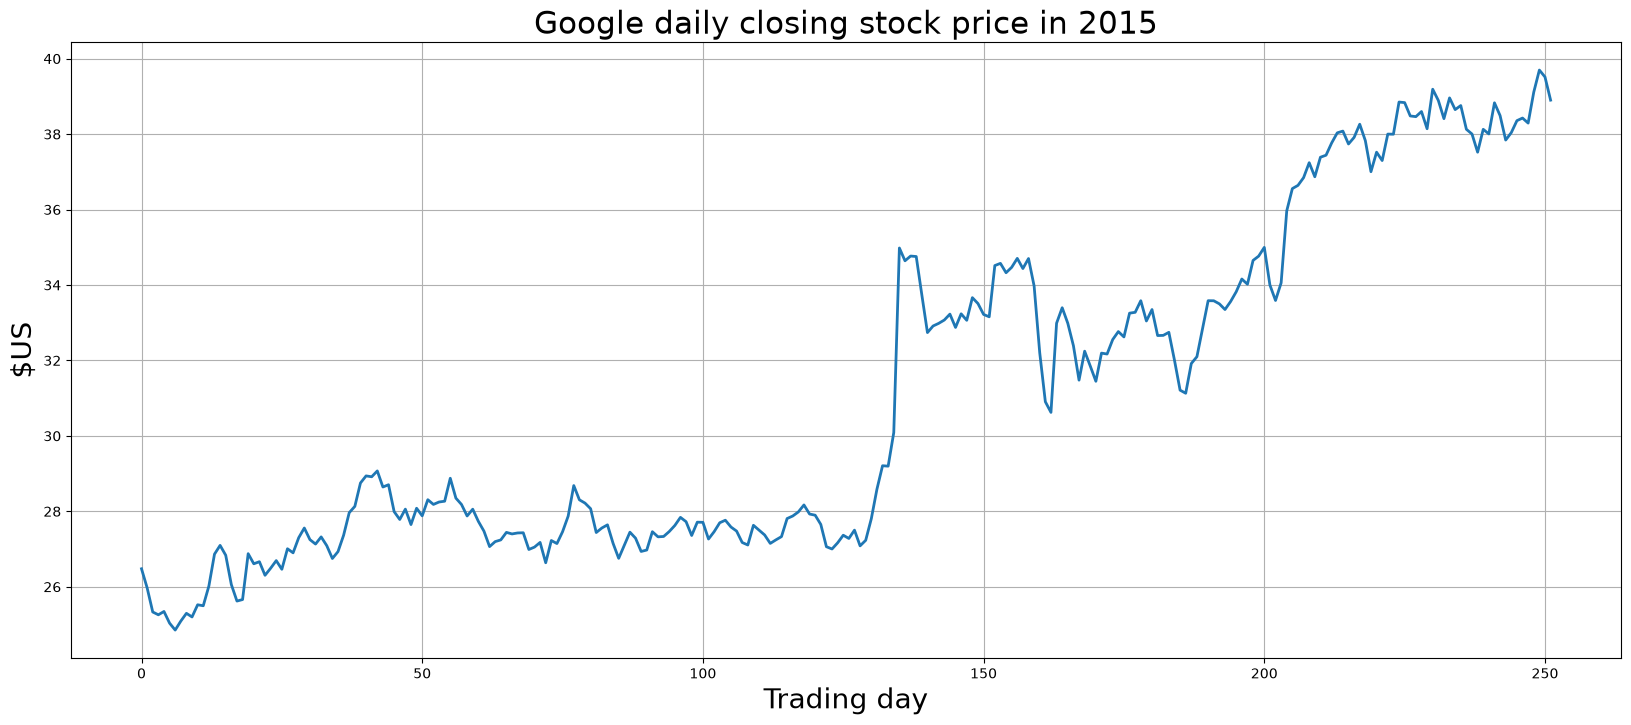

In [17]:
google_stock = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/GOOGL.csv"
)
google_2015 = google_stock[google_stock["Date"] <= "2015-12-31"].copy()

fig, ax = plt.subplots(1, 1, figsize=(20, 8))
google_2015["Close"].plot(ax=ax, linewidth=2)
ax.set_title("Google daily closing stock price in 2015", fontsize=22)
ax.set_ylabel("$US", fontsize=20)
ax.set_xlabel("Trading day", fontsize=20)
ax.grid()

## Остатки наивного прогноза

Для цен акций наивный метод часто оказывается лучшим: $\hat y_t = y_{t-1}$. Тогда остаток — это просто дневное изменение цены:
$$e_t = y_t - y_{t-1}.$$

Соберём вспомогательную функцию, которая строит таблицу «факт / прогноз / остаток».

In [18]:
def augment(model_name, time_var, obs_values, forecast_values=None):
    """DataFrame с фактическими значениями, прогнозами и остатками.

    Если forecast_values не задан — берётся наивный прогноз (значение предыдущего дня).
    """
    df = pd.DataFrame({"Date": time_var.values, "Actual": obs_values.values})
    if forecast_values is None:
        df[model_name] = df["Actual"].shift(1)
    else:
        df[model_name] = np.asarray(forecast_values)
    df["Residuals"] = df["Actual"] - df[model_name]
    return df.dropna()

In [19]:
aug_df = augment(model_name="Naive", time_var=google_2015["Date"], obs_values=google_2015["Close"])
aug_df.head()

,Date,Actual,Naive,Residuals
1,2015-01-05,25.973000,26.477501,-0.504501
2,2015-01-06,25.332001,25.973000,-0.640999
3,2015-01-07,25.257500,25.332001,-0.074501
4,2015-01-08,25.345501,25.257500,0.088001
5,2015-01-09,25.035999,25.345501,-0.309502


### Свойства 1–2: график остатков во времени

Первый и самый дешёвый инструмент диагностики — просто нарисовать остатки по порядку наблюдений. На этом графике мы одновременно проверяем сразу несколько вещей:

- **Нулевое среднее** — облако точек должно быть симметрично относительно нуля (проверим и численно).
- **Отсутствие тренда или структуры** — если остатки систематически растут/падают или образуют «волны», значит модель не уловила закономерность.
- **Постоянство разброса** — амплитуда колебаний должна быть примерно одинаковой слева направо (к этому свойству вернёмся отдельно).

Для наивного прогноза цены Google остаток — это дневное изменение цены. Единственная бросающаяся в глаза аномалия — резкий выброс, соответствующий скачку 17 июля 2015 года.

Среднее остатков: 0.0495


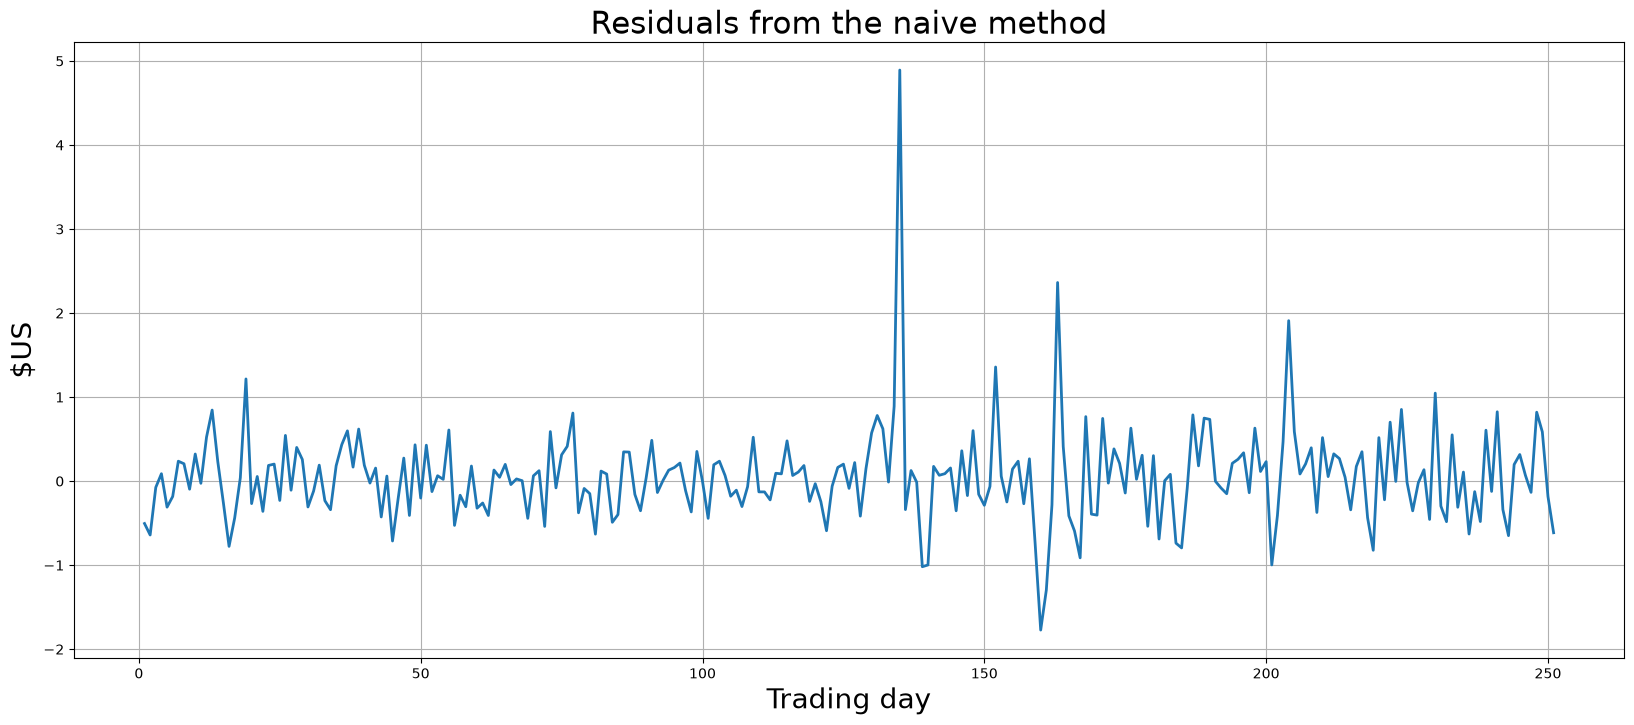

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
aug_df["Residuals"].plot(ax=ax, linewidth=2)
ax.set_title("Residuals from the naive method", fontsize=22)
ax.set_ylabel("$US", fontsize=20)
ax.set_xlabel("Trading day", fontsize=20)
ax.grid()
print("Среднее остатков:", round(aug_df["Residuals"].mean(), 4))

### Свойство 3: постоянство дисперсии (гомоскедастичность)

На графике остатков разброс должен оставаться примерно одинаковым на всём интервале. Если амплитуда колебаний растёт (или падает) со временем, говорят о **гетероскедастичности** — непостоянной дисперсии. Это мешает строить корректные интервалы прогноза.

Оценим свойство двумя способами:

1. **Визуально** — построим *скользящее стандартное отклонение* остатков. У гомоскедастичного ряда эта линия почти горизонтальна.
2. **Формально** — разобьём остатки на две половины и сравним их дисперсии **тестом Левене** ($H_0$: дисперсии равны). Тест Левене предпочтителен, так как в отличие от теста Бартлетта он устойчив к отклонениям от нормальности.

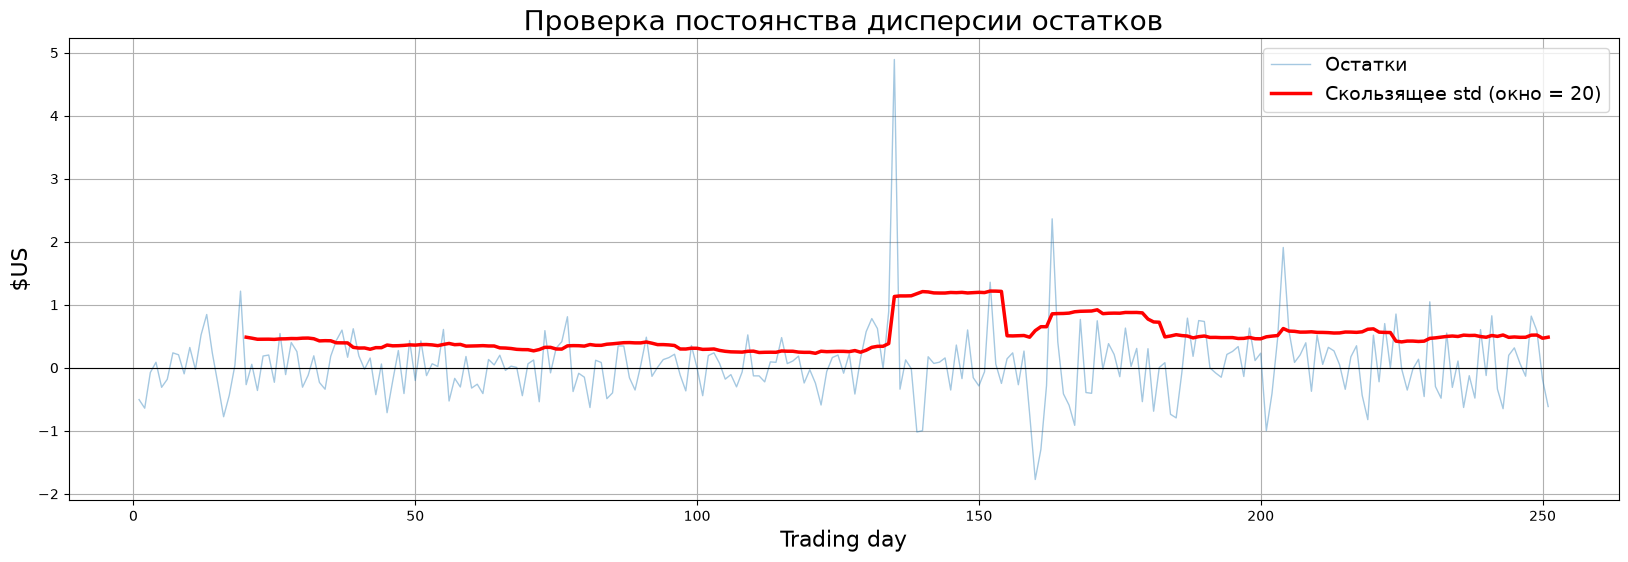

In [21]:
# Скользящее стандартное отклонение остатков (окно 20 торговых дней).
# Если дисперсия постоянна, красная линия должна быть примерно горизонтальной.
roll_std = aug_df["Residuals"].rolling(20).std()

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
aug_df["Residuals"].plot(ax=ax, linewidth=1, alpha=0.4, label="Остатки")
roll_std.plot(ax=ax, linewidth=2.5, color="red", label="Скользящее std (окно = 20)")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("Проверка постоянства дисперсии остатков", fontsize=20)
ax.set_ylabel("$US", fontsize=16)
ax.set_xlabel("Trading day", fontsize=16)
ax.legend(fontsize=14)
ax.grid()
plt.show()

In [22]:
res = aug_df["Residuals"]

# Разобьём ряд остатков на две половины и сравним их дисперсии.
half = len(res) // 2
first_half, second_half = res.iloc[:half], res.iloc[half:]

print(f"Std первой половины:  {first_half.std():.4f}")
print(f"Std второй половины:  {second_half.std():.4f}")

# Тест Левене на равенство дисперсий (устойчив к отклонениям от нормальности).
# H0: дисперсии равны (гомоскедастичность).
lev_stat, lev_p = stats.levene(first_half, second_half)
print(f"\nТест Левене: stat={lev_stat:.3f}, p-value={lev_p:.4f}")
if lev_p < 0.05:
    print("p < 0.05 → дисперсия непостоянна (есть гетероскедастичность)")
else:
    print("p >= 0.05 → нет оснований отвергать постоянство дисперсии")

Std первой половины:  0.3437
Std второй половины:  0.7182

Тест Левене: stat=12.985, p-value=0.0004
p < 0.05 → дисперсия непостоянна (есть гетероскедастичность)


**Как читать результат.** Скользящее стандартное отклонение почти всё время держится на одном уровне, но даёт резкий всплеск в районе июльского выброса. Из-за этого единственного наблюдения дисперсия второй половины ряда оказывается заметно выше первой, и тест Левене формально отвергает гипотезу о постоянстве дисперсии.

Это важный урок: **формальные тесты чувствительны к выбросам**. Здесь непостоянство дисперсии вызвано не структурной гетероскедастичностью, а одним экстраординарным днём. Если исключить выброс, дисперсия выглядит стабильной. Когда же гетероскедастичность реальна (разброс систематически растёт со временем или с уровнем ряда), стандартный приём — **стабилизирующее преобразование** (логарифм или Бокса–Кокса), после которого остатки анализируют заново.

### Свойство 4: нормальность распределения

Нормальность остатков — не обязательное свойство, но при её выполнении интервалы прогноза считаются простыми аналитическими формулами. Начнём с самого наглядного инструмента — **гистограммы**: она позволяет на глаз оценить симметрию, наличие тяжёлых хвостов и выбросов.

У наших остатков правый хвост заметно длиннее, чем у нормального распределения (сказывается июльский выброс) — это стоит держать в уме при построении интервалов прогноза. Ниже мы дополним визуальную оценку **Q–Q графиком** и **формальными тестами**.

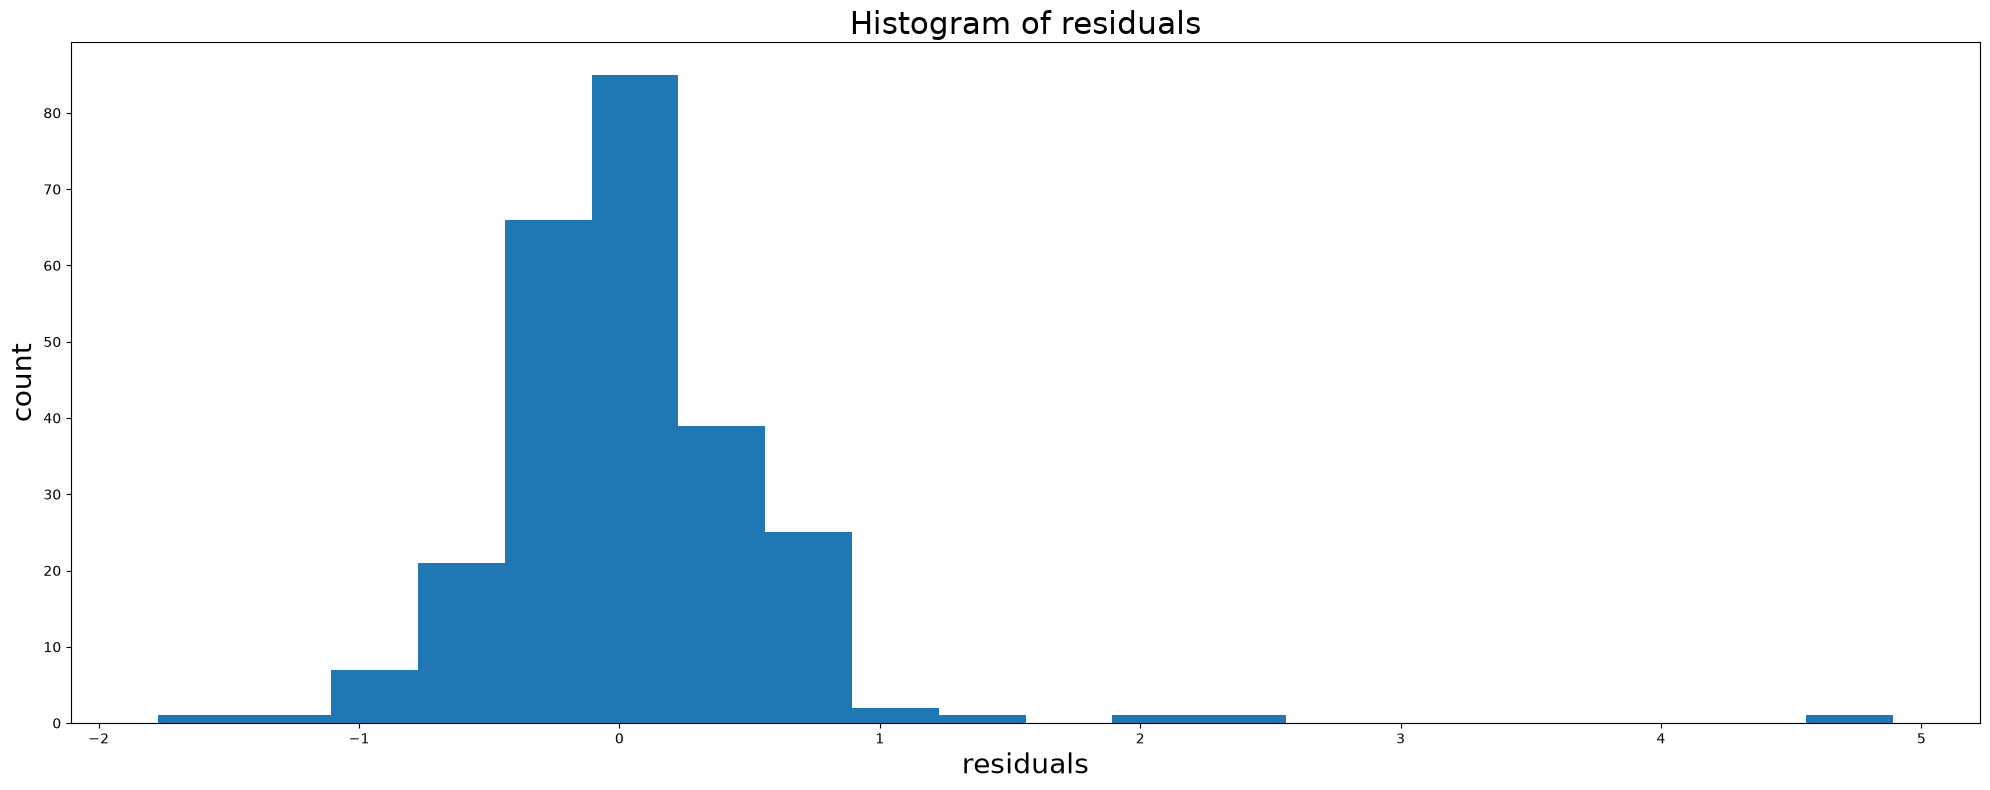

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(20, 8), tight_layout=True)
axs.hist(aug_df["Residuals"], bins=20)
axs.set_title("Histogram of residuals", fontsize=22)
axs.set_ylabel("count", fontsize=20)
axs.set_xlabel("residuals", fontsize=20)
plt.show()

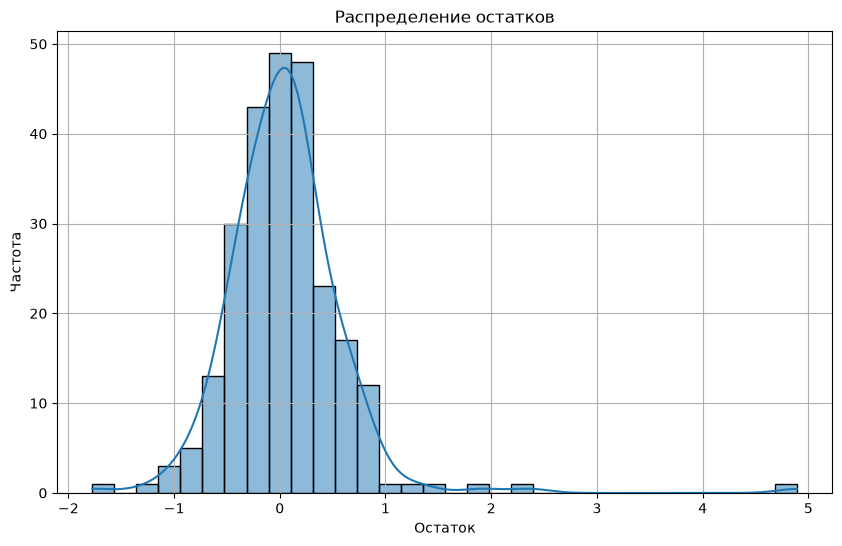

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(aug_df["Residuals"], kde=True)
plt.title("Распределение остатков")
plt.xlabel("Остаток")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

#### Формальные тесты на нормальность

Гистограмма и `kde` — это визуальная оценка. Чтобы проверить нормальность **формально**, применяют статистические тесты. Их нулевая гипотеза $H_0$: «остатки взяты из нормального распределения»; маленький $p$-value ($< 0.05$) означает, что нормальность **отвергается**.

- **Тест Шапиро–Уилка** — один из самых мощных тестов нормальности, хорошо работает на небольших и средних выборках.
- **Тест Жарка–Бера** — основан на выборочных **асимметрии** (skewness) и **эксцессе** (kurtosis); у нормального распределения оба равны нулю.

Дополнительно построим **Q–Q график** (квантиль-квантиль): если остатки нормальны, точки лягут вдоль прямой. Систематические отклонения на концах указывают на тяжёлые хвосты или асимметрию.

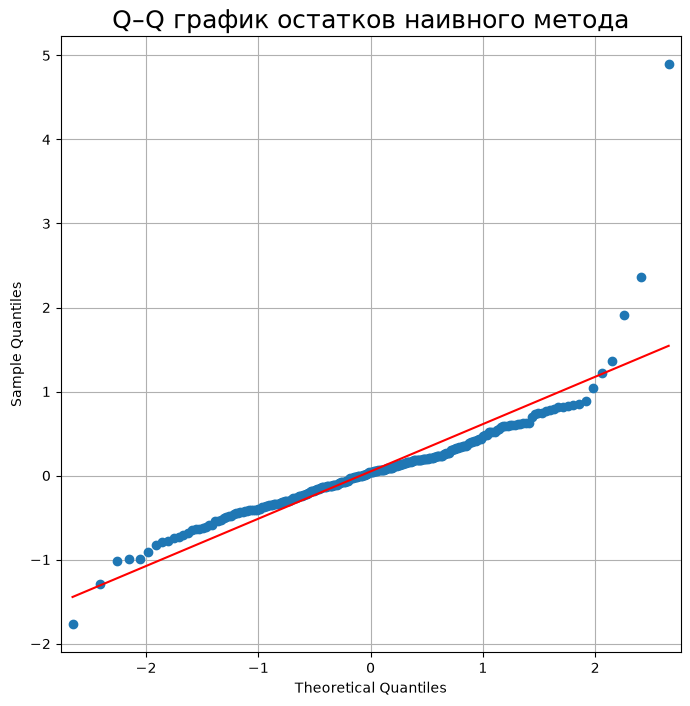

In [25]:
# Q-Q график: сравниваем квантили остатков с квантилями нормального распределения.
# Если остатки нормальны, точки ложатся на прямую (line='s').
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sm.qqplot(aug_df["Residuals"], line="s", ax=ax)
ax.set_title("Q–Q график остатков наивного метода", fontsize=18)
ax.grid()
plt.show()

In [26]:
res = aug_df["Residuals"]

# Тест Шапиро–Уилка: H0 — выборка взята из нормального распределения.
sw_stat, sw_p = stats.shapiro(res)

# Тест Жарка–Бера: проверяет нормальность через асимметрию и эксцесс.
jb_stat, jb_p = stats.jarque_bera(res)

print("H0: остатки нормально распределены\n")
print(f"Shapiro–Wilk:  W  = {sw_stat:.4f},  p-value = {sw_p:.2e}")
print(f"Jarque–Bera:   JB = {jb_stat:.2f},  p-value = {jb_p:.2e}\n")
print(f"Асимметрия (skewness): {stats.skew(res):.3f}  (0 у нормального)")
print(f"Эксцесс (kurtosis):    {stats.kurtosis(res):.3f}  (0 у нормального)\n")

alpha = 0.05
for name, p in [("Shapiro–Wilk", sw_p), ("Jarque–Bera", jb_p)]:
    verdict = "отвергаем H0 → остатки НЕ нормальны" if p < alpha else "не отвергаем H0"
    print(f"{name}: {verdict}")

H0: остатки нормально распределены

Shapiro–Wilk:  W  = 0.8239,  p-value = 3.54e-16
Jarque–Bera:   JB = 5322.20,  p-value = 0.00e+00

Асимметрия (skewness): 2.756  (0 у нормального)
Эксцесс (kurtosis):    21.875  (0 у нормального)

Shapiro–Wilk: отвергаем H0 → остатки НЕ нормальны
Jarque–Bera: отвергаем H0 → остатки НЕ нормальны


**Как интерпретировать.** Оба теста дают крошечные $p$-values ($\ll 0.05$), поэтому гипотеза нормальности **отвергается**. Причина видна и на гистограмме, и на Q–Q графике: положительная асимметрия и тяжёлые хвосты, порождённые прежде всего июльским выбросом. Крупная положительная величина эксцесса подтверждает «тяжесть» хвостов.

Практический вывод такой же, как в классическом примере Хайндмана: наивный прогноз, скорее всего, достаточно хорош по точности (остатки некоррелированы), **но** интервалы прогноза, построенные в предположении нормальности, будут неточны. В подобных случаях интервалы строят без опоры на нормальность — например, бутстрэпом остатков.

> ⚠️ На больших выборках формальные тесты нормальности почти всегда отвергают $H_0$ даже при незначительных отклонениях. Поэтому их всегда полезно сопровождать визуальной оценкой (гистограмма + Q–Q график) и содержательным анализом выбросов.

### Факт против прогноза

Если прогноз идеален, точки лежат на диагонали (красная линия). Разброс вокруг неё — это и есть остатки.

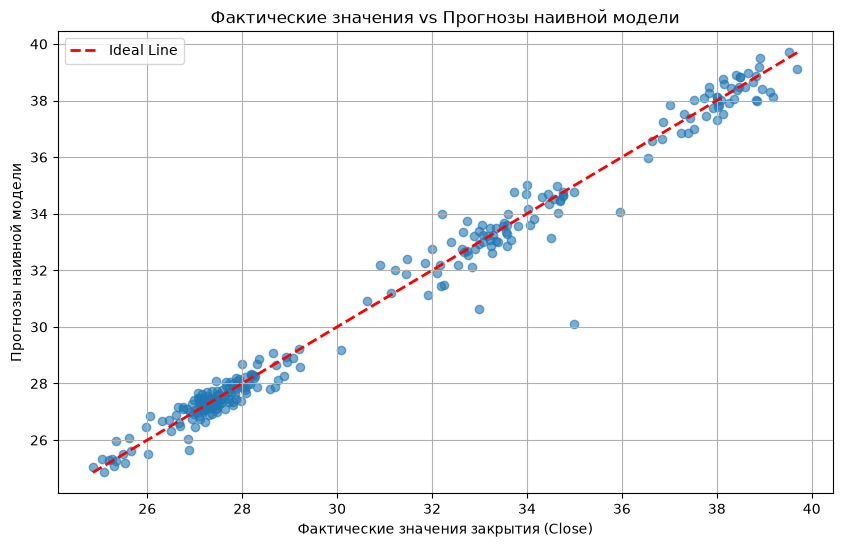

In [27]:
actual = aug_df["Actual"]
forecast = aug_df["Naive"]

plt.figure(figsize=(10, 6))
plt.scatter(actual, forecast, alpha=0.6)
plt.plot(
    [actual.min(), actual.max()], [actual.min(), actual.max()], "r--", lw=2, label="Ideal Line"
)
plt.title("Фактические значения vs Прогнозы наивной модели")
plt.xlabel("Фактические значения закрытия (Close)")
plt.ylabel("Прогнозы наивной модели")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
residuals = actual - forecast
mse = np.mean(residuals**2)
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(mse)
print(f"MSE:  {mse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE:  0.32
MAE:  0.37
RMSE: 0.57


### Свойство 1: автокорреляция остатков (ACF)

Построим выборочную ACF остатков. Значения, выходящие за границы $\pm 2/\sqrt{n}$ (красные пунктиры), указывают на статистически значимую автокорреляцию. Для белого шума почти все всплески должны быть внутри границ.

Text(0, 0.5, 'ACF')

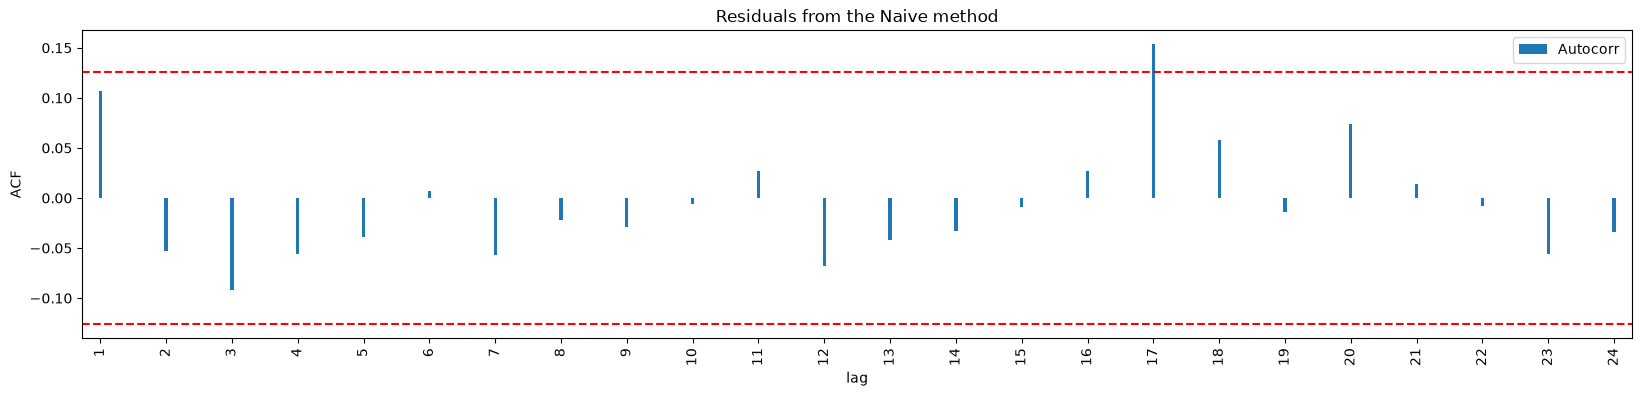

In [29]:
ticker_data = aug_df["Residuals"]
ticker_data_acf = [ticker_data.autocorr(i) for i in range(1, 25)]

acf_df = pd.DataFrame([ticker_data_acf]).T
acf_df.columns = ["Autocorr"]
acf_df.index += 1
acf_df.plot(kind="bar", width=0.05, figsize=(20, 4))

n = len(aug_df["Residuals"])
plt.axhline(y=2 / math.sqrt(n), color="r", linestyle="dashed")
plt.axhline(y=-2 / math.sqrt(n), color="r", linestyle="dashed")
plt.title("Residuals from the Naive method")
plt.xlabel("lag")
plt.ylabel("ACF")

## Формальные тесты автокорреляции (portmanteau)

Разглядывание ACF — это неявно множество проверок гипотез, и при большом числе лагов легко получить ложное срабатывание. Поэтому проверяют **всю группу** первых $\ell$ автокорреляций сразу.

**Тест Бокса–Пирса:** $\;Q = n\sum_{k=1}^{\ell} r_k^2$.

**Тест Льюнга–Бокса** (точнее для малых выборок): $\;Q^{*} = n(n+2)\sum_{k=1}^{\ell}(n-k)^{-1} r_k^2$.

При гипотезе белого шума статистика имеет распределение $\chi^2$ с $(\ell - K)$ степенями свободы, где $K$ — число параметров модели. Рекомендуется $\ell=10$ для несезонных данных. У наивного прогноза параметров нет, но `acorr_ljungbox` требует `model_df`; возьмём его как в исходном примере.

In [30]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [31]:
acf_frame = acf_df[["Autocorr"]]

df_box_pierce = acorr_ljungbox(acf_frame, lags=10, boxpierce=True, model_df=1)
df_box_pierce[["bp_stat", "bp_pvalue"]].tail(1)

,bp_stat,bp_pvalue
10,3.972065,0.913241


In [32]:
ljung_box = acorr_ljungbox(acf_frame, lags=10, model_df=1)
ljung_box.tail(1)

,lb_stat,lb_pvalue
10,5.238627,0.81303


Большие $p$-values (тест не значим) означают, что остатки **неотличимы от белого шума**. Значит, наивный метод использует практически всю доступную информацию; но из-за неидеальной нормальности интервалы прогноза, построенные в предположении нормальности, могут быть неточны.

## То же для метода дрейфа

Метод дрейфа имеет один оцениваемый параметр — сам дрейф (средний дневной прирост):
$$\hat y_t = y_{t-1} + \frac{y_n - y_1}{n-1}.$$

Посчитаем одношаговые остатки дрейфа явно и применим тест Льюнга–Бокса с `model_df=1` (учёт одного параметра).

In [33]:
y = google_2015["Close"].to_numpy()
drift = (y[-1] - y[0]) / (len(y) - 1)  # оценка дрейфа
fitted_drift = google_2015["Close"].shift(1) + drift  # одношаговый прогноз

aug_df_drift = augment(
    model_name="Drift",
    time_var=google_2015["Date"],
    obs_values=google_2015["Close"],
    forecast_values=fitted_drift,
)
print("Оценка дрейфа (средний дневной прирост):", round(drift, 4))
aug_df_drift.head()

Оценка дрейфа (средний дневной прирост): 0.0495


,Date,Actual,Drift,Residuals
1,2015-01-05,25.973000,26.526995,-0.553995
2,2015-01-06,25.332001,26.022494,-0.690493
3,2015-01-07,25.257500,25.381495,-0.123995
4,2015-01-08,25.345501,25.306994,0.038507
5,2015-01-09,25.035999,25.394995,-0.358996


In [34]:
ticker_data = aug_df_drift["Residuals"]
ticker_data_acf = [ticker_data.autocorr(i) for i in range(1, 25)]
acf_df_drift = pd.DataFrame([ticker_data_acf]).T
acf_df_drift.columns = ["Autocorr"]
acf_df_drift.index += 1

ljung_box = acorr_ljungbox(acf_df_drift[["Autocorr"]], lags=10, model_df=1)
ljung_box.tail(1)

,lb_stat,lb_pvalue
10,5.238627,0.81303


Как и у наивного метода, остатки дрейфа неотличимы от белого шума.

## Пример: остатки «плохой» модели

До сих пор мы разбирали методы, которые проходят диагностику. Полезно посмотреть на противоположный случай — модель, которая **не** улавливает структуру ряда, и научиться распознавать это по остаткам.

Возьмём заведомо плохую для трендового ряда модель — **прогноз по среднему**: $\hat y_t = \bar y$, где $\bar y$ — среднее всех наблюдений. Цена акций Google в 2015 году в целом росла, поэтому единая константа систематически недооценивает ряд в конце и переоценивает в начале. Посмотрим, как это проявится в остатках.

Прогноз (среднее цены): 31.00
Среднее остатков:       -0.0000


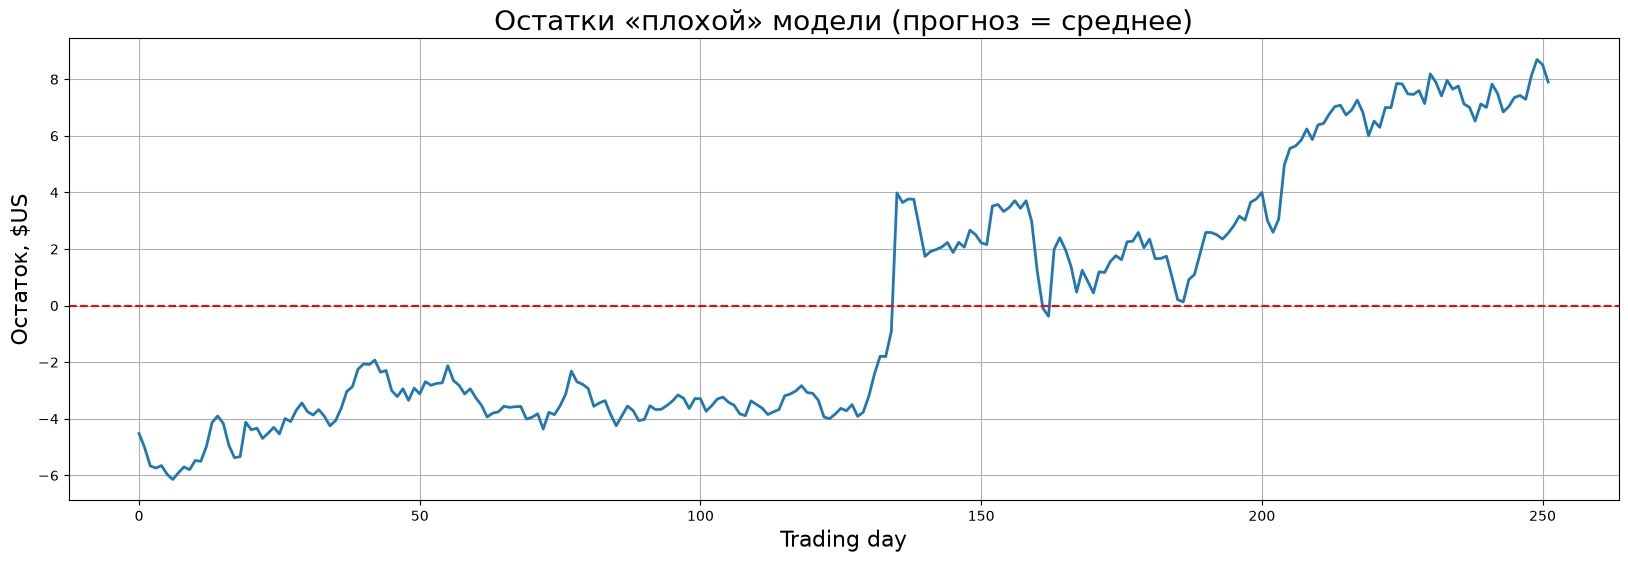

In [35]:
# «Плохая» модель: прогноз = среднее значение цены по всей истории.
# Такая модель полностью игнорирует тренд ряда.
mean_value = google_2015["Close"].mean()
mean_forecast = pd.Series(mean_value, index=google_2015.index)

aug_bad = augment(
    model_name="Mean",
    time_var=google_2015["Date"],
    obs_values=google_2015["Close"],
    forecast_values=mean_forecast,
)

print(f"Прогноз (среднее цены): {mean_value:.2f}")
print(f"Среднее остатков:       {aug_bad['Residuals'].mean():.4f}")

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
aug_bad["Residuals"].plot(ax=ax, linewidth=2)
ax.axhline(0, color="r", linestyle="dashed")
ax.set_title("Остатки «плохой» модели (прогноз = среднее)", fontsize=20)
ax.set_ylabel("Остаток, $US", fontsize=16)
ax.set_xlabel("Trading day", fontsize=16)
ax.grid()
plt.show()

Обратите внимание: **среднее остатков равно нулю** (по построению), поэтому по одному этому критерию модель могла бы показаться приемлемой. Но график остатков — это, по сути, вычтенная константа из трендового ряда: чётко видна «волна» — сначала остатки отрицательные, потом положительные. Такая структура — верный признак того, что модель не уловила тренд.

Формализуем это через ACF и тест Льюнга–Бокса.

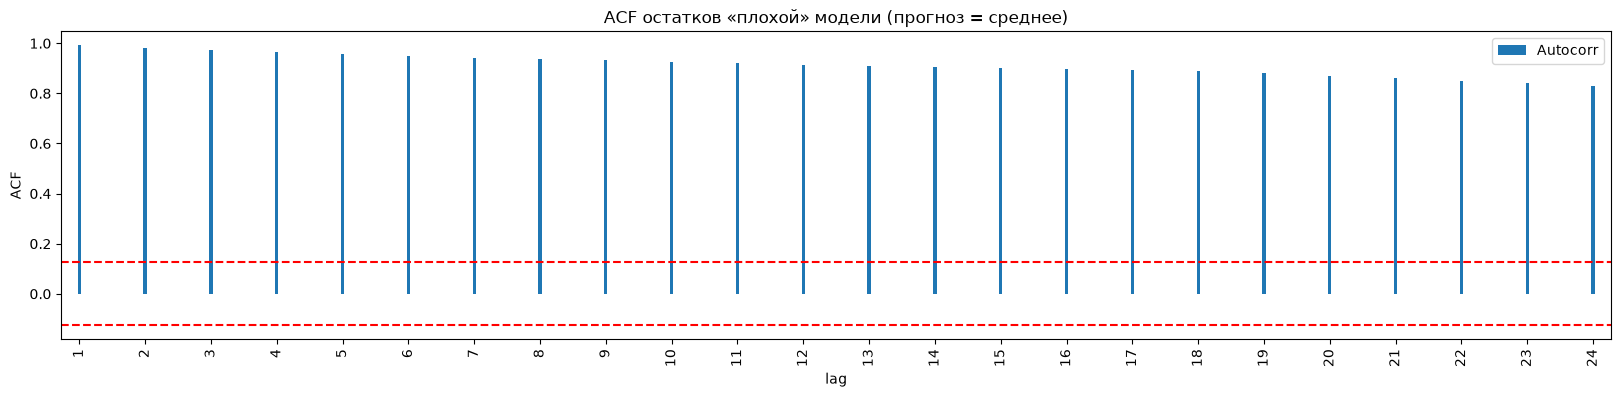

In [36]:
res_bad = aug_bad["Residuals"]
acf_bad = [res_bad.autocorr(i) for i in range(1, 25)]
acf_bad_df = pd.DataFrame([acf_bad]).T
acf_bad_df.columns = ["Autocorr"]
acf_bad_df.index += 1
acf_bad_df.plot(kind="bar", width=0.05, figsize=(20, 4))

n_bad = len(res_bad)
plt.axhline(y=2 / math.sqrt(n_bad), color="r", linestyle="dashed")
plt.axhline(y=-2 / math.sqrt(n_bad), color="r", linestyle="dashed")
plt.title("ACF остатков «плохой» модели (прогноз = среднее)")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.show()

In [37]:
# Формальный тест Льюнга–Бокса для остатков плохой модели.
# H0: остатки — белый шум (автокорреляции незначимы).
lb_bad = acorr_ljungbox(acf_bad_df[["Autocorr"]], lags=10, model_df=0)
print(lb_bad[["lb_stat", "lb_pvalue"]].tail(1))

lb_p_bad = lb_bad["lb_pvalue"].iloc[-1]
print(
    "\nВывод:",
    "p < 0.05 → остатки НЕ являются белым шумом, модель плохая"
    if lb_p_bad < 0.05
    else "p >= 0.05 → остатки похожи на белый шум",
)

     lb_stat     lb_pvalue
10  55.26682  2.815548e-08

Вывод: p < 0.05 → остатки НЕ являются белым шумом, модель плохая


### Что с этим делать?

Диагностика чётко говорит: остатки содержат **неиспользованную структуру**, значит модель плохая и её можно (и нужно) улучшить. Возможные шаги:

1. **Сменить модель на более адекватную структуре ряда.** У ряда есть тренд — значит модель обязана его учитывать. Наивный метод или метод дрейфа (см. выше) уже дают остатки, неотличимые от белого шума: сильная автокорреляция исчезает.
2. **Если остатки коррелированы — добавить динамику.** Автокорреляция в остатках — сигнал, что нужны лаги/скользящее среднее (модели ARIMA), сезонные компоненты или экзогенные признаки.
3. **Если нарушена дисперсия/нормальность — преобразовать ряд** (логарифм, Бокса–Кокса) или строить интервалы прогноза без опоры на нормальность.

**Главный вывод.** Прежде чем доверять прогнозу, всегда смотрите на остатки. «Плохая» модель выдаёт себя не значением метрики, а структурой остатков: тренд на графике, всплески на ACF и значимый тест Льюнга–Бокса. Диагностика остатков — это дешёвый и надёжный способ понять, что модель ещё не дотягивает.

## Выводы

- Анализ остатков отвечает на вопрос: «выжали ли мы из ряда всю информацию?». Ориентир — **белый шум**.
- **Полный набор диагностик** остатков:
  - график остатков во времени — среднее, тренд, разброс;
  - **дисперсия** (свойство 3): скользящее std + тест Левене на равенство дисперсий;
  - **распределение** (свойство 4): гистограмма/`kde`, Q–Q график и формальные тесты нормальности (**Шапиро–Уилка**, **Жарка–Бера**);
  - **автокорреляция** (свойство 1): ACF с границами $\pm 2/\sqrt{n}$ и формальный тест **Льюнга–Бокса**.
- Свойства 1–2 (некоррелированность, нулевое среднее) критичны для **точности** прогноза; свойства 3–4 (постоянство дисперсии, нормальность) — для корректных **интервалов** прогноза.
- Формальные тесты нужно читать вместе с графиками: на больших выборках они чувствительны к малым отклонениям и к отдельным выбросам (как июльский скачок Google).
- «Плохая» модель выдаёт себя структурой остатков (тренд, всплески ACF, значимый Льюнг–Бокс), а не только метрикой. Диагностика подсказывает и лечение: сменить модель, добавить динамику/сезонность или применить преобразование ряда.
- Полезно завести собственную функцию диагностики остатков и постепенно её дорабатывать.